In [236]:
# --- import libraries ---
import pandas as pd
import numpy as np
import os
import shutil
from lifelines import CoxPHFitter
from lifelines.exceptions import ConvergenceError
from sklearn.preprocessing import StandardScaler
from typing import Tuple, Optional
import matplotlib.pyplot as plt
import seaborn as sns

PARTICIPANT_DATA_PATH = './participant_data/'

## Method 1: Default Method

In [237]:
from utilities.preprocess import preprocess

index_event = "Borrow"
outcome_event = "Liquidated"
dataset_path = os.path.join(index_event, outcome_event)

train_df = pd.read_csv(os.path.join(PARTICIPANT_DATA_PATH, dataset_path, 'train.csv'))
test_features_df = pd.read_csv(os.path.join(PARTICIPANT_DATA_PATH, dataset_path, 'test_features.csv'))

X_train, y_train, X_test_processed = preprocess(train_df, test_features_df)

lifelines_train_df = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)

model = CoxPHFitter(penalizer=0.1)
model.fit(lifelines_train_df, duration_col='timeDiff', event_col='status')

<lifelines.CoxPHFitter: fitted with 885908 total observations, 861864 right-censored observations>

In [238]:
lifelines_train_df.head()

,userBorrowSum,marketWithdrawAvgAmount,marketDepositAvgAmountUSD,sinDayOfMonth,userSecondsSinceFirstTransaction,timeOfDay,userActiveDaysWeekly,userLiquidationCount,userActiveDaysMonthly,userRepayCount,cosQuarter,marketRepayAvgAmount,marketLiquidationSum,userLiquidationSum,sinDayOfQuarter,marketLiquidationCount,userRepaySumUSD,userWithdrawCount,marketRepayCount,userLiquidationSumUSD,marketWithdrawSum,userWithdrawSumUSD,marketBorrowSum,marketLiquidationAvgAmountUSD,userDepositSumUSD,quarter,userBorrowAvgAmount,marketWithdrawCount,userRepayAvgAmount,dayOfQuarter,cosDayOfQuarter,userWithdrawSum,dayOfMonth,dayOfYear,marketDepositSumUSD,userDepositSum,priceInUSD,userLiquidationAvgAmountUSD,marketBorrowAvgAmount,userRepayAvgAmountUSD,userWithdrawAvgAmountUSD,userWithdrawAvgAmount,marketBorrowCount,userActiveDaysYearly,marketRepaySumUSD,userLiquidationAvgAmount,amount,marketDepositSum,amountUSD,marketBorrowAvgAmountUSD,marketWithdrawSumUSD,marketDepositAvgAmount,userDepositAvgAmountUSD,userBorrowCount,dayOfWeek,cosDayOfMonth,marketRepaySum,sinTimeOfDay,userBorrowSumUSD,cosTimeOfDay,cosDayOfWeek,marketWithdrawAvgAmountUSD,marketLiquidationSumUSD,userDepositAvgAmount,sinDayOfYear,userDepositCount,cosDayOfYear,logAmount,sinDayOfWeek,userBorrowAvgAmountUSD,userSecondsSincePreviousTransaction,marketBorrowSumUSD,userRepaySum,logAmountUSD,marketDepositCount,marketRepayAvgAmountUSD,sinQuarter,marketLiquidationAvgAmount,timeDiff,status
0,-0.398558,-2.489321,-2.099994,0.289315,-0.785666,-0.570639,-0.396655,-0.156334,-0.892979,-0.402879,-0.095643,-2.342678,-0.644883,-0.045902,-1.277559,-1.286067,-0.397683,-0.057835,-3.616429,-0.0872,-1.292936,-0.170998,-1.761493,-1.361321,-0.112514,-1.452898,-0.456487,-1.387211,-0.46772,1.015363,0.589542,-0.15118,-0.185892,-1.161545,-1.423436,-0.120943,-0.226747,-0.10614,-1.806487,-0.486161,-0.295377,-0.244026,-2.240522,-0.690296,-1.707336,-0.075548,-0.357465,-1.352890,-0.420648,-1.828478,-1.34988,-2.163606,-0.276391,-0.439298,-1.448052,-1.354495,-1.726414,1.148620,-0.397778,-0.743173,0.978175,-2.456185,-0.832493,-0.170569,1.387732,-0.237205,0.373454,-1.011497,1.050891,-0.485221,-0.079284,-1.733569,-0.398471,-1.254174,-1.577749,-2.370232,1.542022,-0.932965,75264503.0,0.0
1,-0.398558,-2.487828,-2.099970,-0.306477,-0.797257,-0.545239,-1.190754,-0.156334,-1.072193,-0.402879,-0.095643,-2.342678,-0.644883,-0.045902,-1.189663,-1.286067,-0.397683,-0.057835,-3.616429,-0.0872,-1.292936,-0.170998,-1.761493,-1.361321,-0.112515,-1.452898,-0.456516,-1.387187,-0.46772,1.093143,0.763696,-0.15118,0.043339,-1.142780,-1.423436,-0.120943,-0.226747,-0.10614,-1.806539,-0.486161,-0.295377,-0.244026,-2.240461,-0.720544,-1.707336,-0.075548,-0.357486,-1.352890,-0.420668,-1.828521,-1.34988,-2.163563,-0.276395,-0.439298,-0.420731,-1.354495,-1.726414,1.108079,-0.397778,-0.788563,-1.183281,-2.455039,-0.832493,-0.170569,1.401740,-0.239892,0.325844,-1.139566,0.557057,-0.485246,-0.130458,-1.733569,-0.398471,-1.382937,-1.577674,-2.370232,1.542022,-0.932965,75091115.0,0.0
2,-0.398558,-2.487828,-2.097217,-0.306477,-0.797492,-0.276081,-1.190754,-0.156334,-1.072193,-0.402879,-0.095643,-2.342678,-0.644883,-0.045902,-1.189663,-1.286067,-0.397683,-0.057835,-3.616429,-0.0872,-1.292936,-0.170998,-1.761493,-1.361321,-0.112512,-1.452898,-0.456487,-1.387187,-0.46772,1.093143,0.763696,-0.15118,0.043339,-1.142780,-1.423435,-0.120939,-0.226747,-0.10614,-1.806522,-0.486161,-0.295377,-0.244026,-2.240399,-0.720544,-1.707336,-0.075548,-0.357465,-1.352889,-0.420648,-1.828507,-1.34988,-2.159853,-0.275485,-0.439298,-0.420731,-1.354495,-1.726414,0.575966,-0.397778,-1.148216,-1.183281,-2.455039,-0.832493,-0.169505,1.401740,-0.239892,0.325844,-1.011497,0.557057,-0.485221,-0.132896,-1.733569,-0.398471,-1.254154,-1.577637,-2.370232,1.542022,-0.932965,75084884.0,0.0
3,-0.398558,-2.487828,-2.097217,-0.306477,-0.797489,-0.274353,-1.190754,-0.156334,-1.072193,-0.402879,-0.095643,-2.342678,-0.644883,-0.045902,-1.189663,-1.286067,-0.397683,-0.057835,-3.616429,-0.0872,-1.292936

In [239]:
lifelines_train_df.shape

(885908, 80)

In [240]:
# model.print_summary()
from lifelines.utils import concordance_index

train_risk = model.predict_partial_hazard(X_train)

# --- c-index using partial hazard as risk scores ---
c_index = concordance_index(
    lifelines_train_df["timeDiff"],       # observed times
    -train_risk,                          # negative because higher risk -> shorter survival
    lifelines_train_df["status"]          # event indicator
)
print(f"C-Index: {c_index:.3f}")

C-Index: 0.814


In [241]:
summary_df = model.summary
summary_df.head()

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
userBorrowSum,-0.043944,0.957007,0.003270,-0.050353,-0.037536,0.950894,0.963160,0.0,-13.440306,3.509845e-41,134.387644
marketWithdrawAvgAmount,0.001245,1.001245,0.003100,-0.004830,0.007320,0.995181,1.007346,0.0,0.401535,6.880264e-01,0.539464
marketDepositAvgAmountUSD,0.012842,1.012924,0.003168,0.006633,0.019050,1.006655,1.019233,0.0,4.053685,5.041716e-05,14.275726
sinDayOfMonth,0.017731,1.017889,0.003019,0.011813,0.023649,1.011883,1.023931,0.0,5.872272,4.298617e-09,27.793480
userSecondsSinceFirstTransaction,0.026481,1.026835,0.003008,0.020585,0.032377,1.020798,1.032907,0.0,8.802642,1.336323e-18,59.376436


## Method 2: Select Relevant Features & Train

In [242]:
covariates = summary_df.index.tolist()      
hr = summary_df['exp(coef)'].to_list()
p_values = summary_df['p'].to_list()
len(covariates), len(hr), len(p_values)                           

(78, 78, 78)

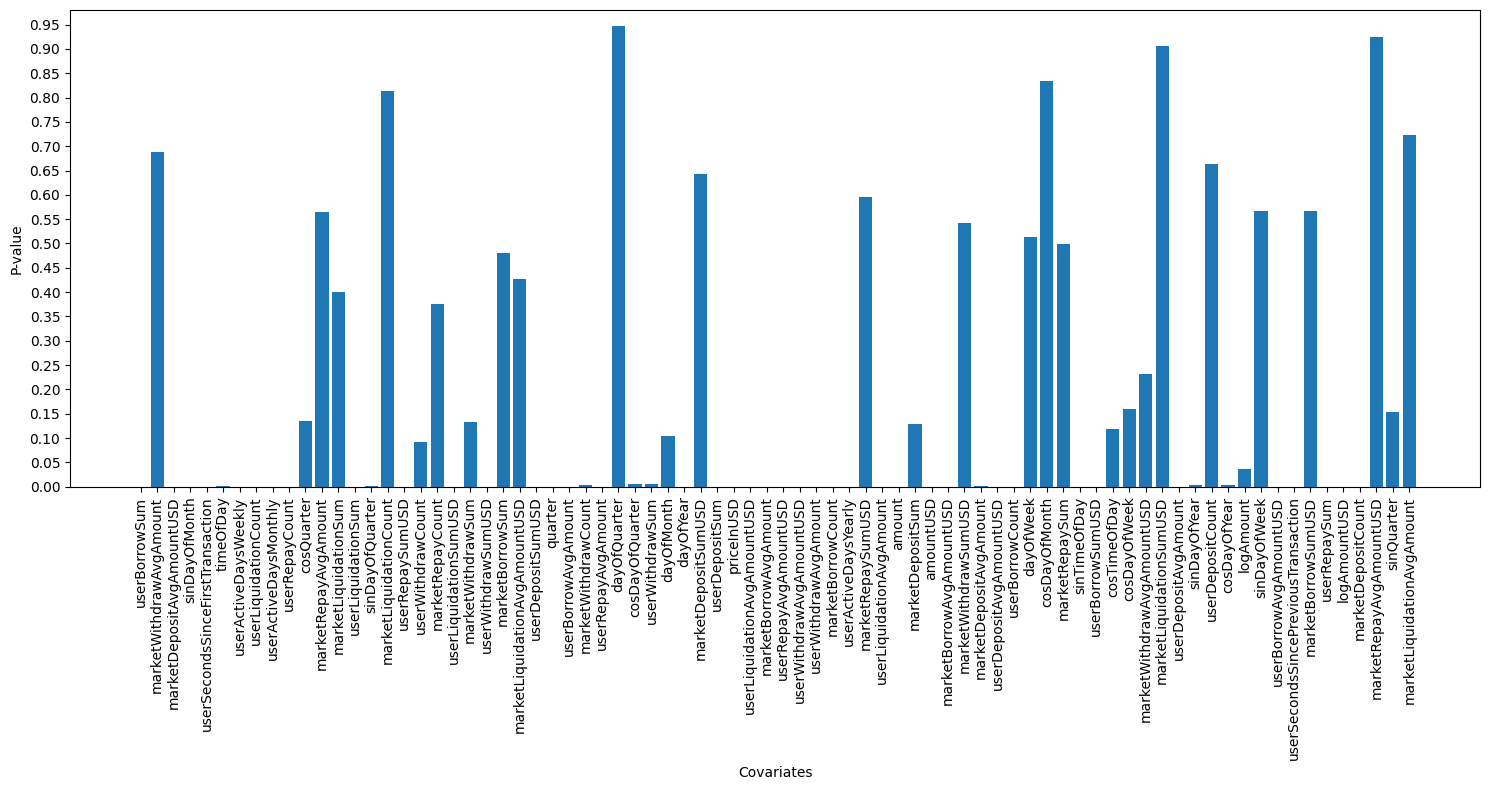

In [243]:
plt.figure(figsize=(15,8))  
plt.bar(covariates, p_values)

plt.ylim(0, 0.98)  
plt.yticks(np.arange(0, 0.98, 0.05))  

plt.xticks(rotation=90)  
plt.xlabel('Covariates')   
plt.ylabel('P-value')   
plt.tight_layout()          
plt.show()

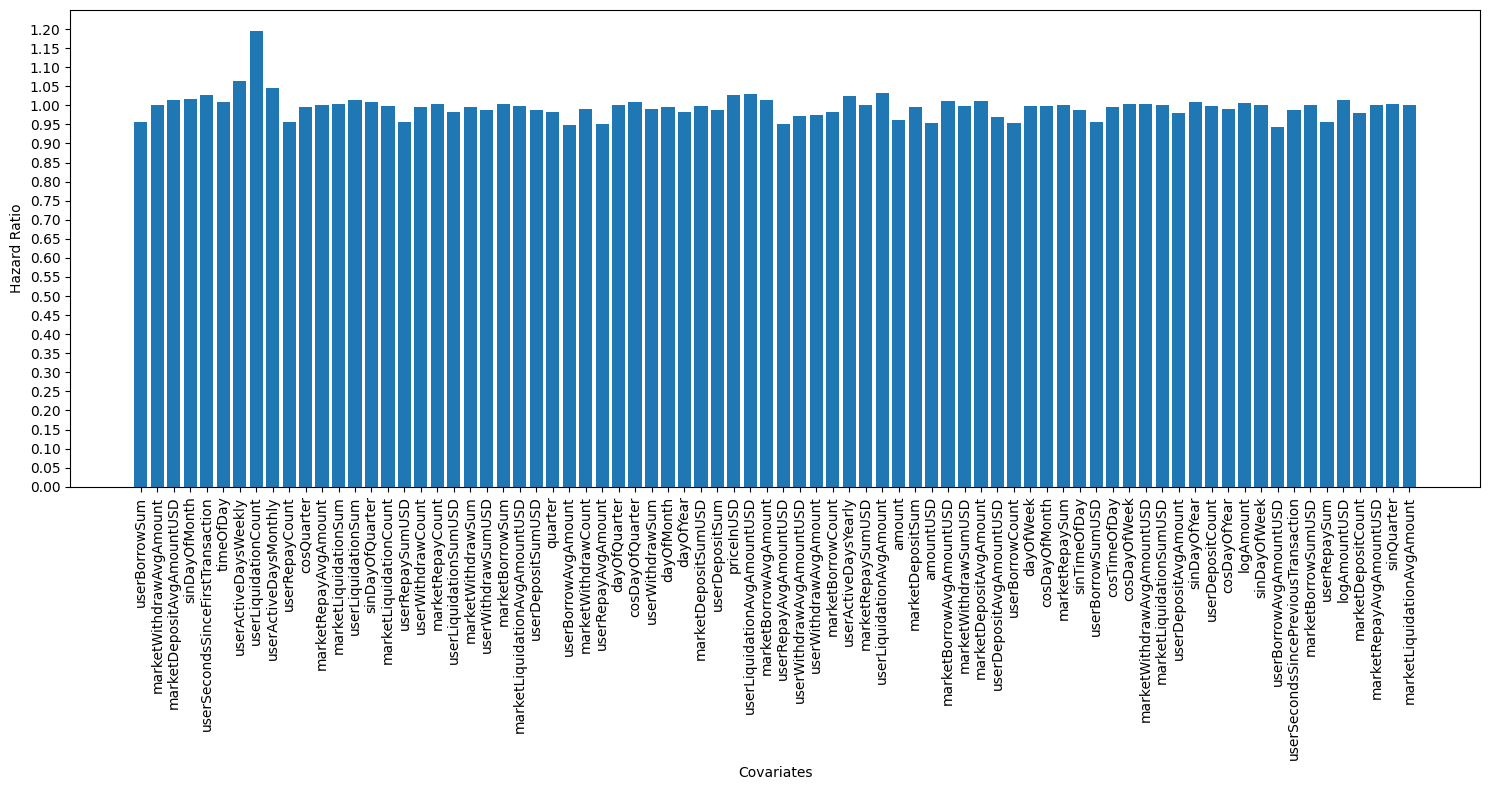

In [244]:
plt.figure(figsize=(15,8))  
plt.bar(covariates, hr)
plt.xticks(rotation=90)  

plt.ylim(0, 1.25)  
plt.yticks(np.arange(0, 1.25, 0.05))  

plt.xlabel('Covariates')   
plt.ylabel('Hazard Ratio')   
plt.tight_layout()          
plt.show()

In [269]:
##-- select features with both low p-value and meaningful HR --##
    # keep covariates with HR < 0.8 or HR > 1.2, provided p < 0.05.
    # be cautious with HR ≈ 1.0 (like 0.98–1.02) -> effect is negligible

# coef -> regression coefficient (β)
# exp(coef) -> Hazard Ratio (HR) = exp(β) (row['p'] >= 0.001) and 

cols_to_keep = []
for index, row in summary_df.iterrows():
    if row['p'] <= 0.0005 and (row['exp(coef)'] < 0.99 or row['exp(coef)'] > 1.1): # means only features that change hazard by less than ±20% are dropped
        cols_to_keep.append(index)

print(len(cols_to_keep))

27


In [270]:
index_event = "Borrow"
outcome_event = "Liquidated"
dataset_path = os.path.join(index_event, outcome_event)
new_train_df = pd.read_csv(os.path.join(PARTICIPANT_DATA_PATH, dataset_path, 'train.csv'))

new_train_df = new_train_df[cols_to_keep + ['timeDiff', 'status']]
new_train_df.shape

(885908, 29)

In [271]:
new_train_df.head()

,userBorrowSum,userLiquidationCount,userRepayCount,userRepaySumUSD,userLiquidationSumUSD,userWithdrawSumUSD,userDepositSumUSD,quarter,userBorrowAvgAmount,userRepayAvgAmount,dayOfYear,userDepositSum,userRepayAvgAmountUSD,userWithdrawAvgAmountUSD,userWithdrawAvgAmount,marketBorrowCount,amount,amountUSD,userDepositAvgAmountUSD,userBorrowCount,sinTimeOfDay,userBorrowSumUSD,userDepositAvgAmount,userBorrowAvgAmountUSD,userSecondsSincePreviousTransaction,userRepaySum,marketDepositCount,timeDiff,status
0,1.00000,0,0,0.0,0.0,0.0,4.802613,1,1.00000,0.0,73.0,4.0,0.0,0.0,0.0,1.0,1.00000,0.999892,1.200653,1,0.765624,0.999892,1.0,0.999892,64356.0,0.0,5.0,75264503.0,0.0
1,0.20000,0,0,0.0,0.0,0.0,1.000000,1,0.20000,0.0,75.0,1.0,0.0,0.0,0.0,2.0,0.20000,0.199924,1.000000,1,0.737425,0.199924,1.0,0.199924,3185.0,0.0,9.0,75091115.0,0.0
2,1.00000,0,0,0.0,0.0,0.0,50.000000,1,1.00000,0.0,75.0,50.0,0.0,0.0,0.0,3.0,1.00000,1.000053,50.000000,1,0.367313,1.000053,50.0,1.000053,270.0,0.0,11.0,75084884.0,0.0
3,6.00000,0,0,0.0,0.0,0.0,50.000000,1,3.00000,0.0,75.0,50.0,0.0,0.0,0.0,4.0,5.00000,5.000000,50.000000,2,0.364606,6.000053,50.0,3.000026,40.0,0.0,11.0,75084844.0,0.0
4,0.79299,0,0,0.0,0.0,0.0,14.078625,1,0.79299,0.0,75.0,10.0,0.0,0.0,0.0,5.0,0.79299,0.793127,14.078625,1,0.000436,0.793127,10.0,0.793127,328.0,0.0,13.0,75079718.0,0.0


In [272]:
from utilities.preprocess import preprocess

print("Preprocessing data...")
X_train_new, y_train_new, X_test_processed = preprocess(new_train_df, test_features_df)
new_lifelines_train_df = pd.concat([X_train_new, y_train_new.reset_index(drop=True)], axis=1)
new_lifelines_train_df.head()

Preprocessing data...


,userBorrowSum,userLiquidationCount,userRepayCount,userRepaySumUSD,userLiquidationSumUSD,userWithdrawSumUSD,userDepositSumUSD,quarter,userBorrowAvgAmount,userRepayAvgAmount,dayOfYear,userDepositSum,userRepayAvgAmountUSD,userWithdrawAvgAmountUSD,userWithdrawAvgAmount,marketBorrowCount,amount,amountUSD,userDepositAvgAmountUSD,userBorrowCount,sinTimeOfDay,userBorrowSumUSD,userDepositAvgAmount,userBorrowAvgAmountUSD,userSecondsSincePreviousTransaction,userRepaySum,marketDepositCount,timeDiff,status
0,-0.398558,-0.156334,-0.402879,-0.397683,-0.0872,-0.170998,-0.112514,-1.452898,-0.456487,-0.46772,-1.161545,-0.120943,-0.486161,-0.295377,-0.244026,-2.240522,-0.357465,-0.420648,-0.276391,-0.439298,1.148620,-0.397778,-0.170569,-0.485221,-0.079284,-0.398471,-1.577749,75264503.0,0.0
1,-0.398558,-0.156334,-0.402879,-0.397683,-0.0872,-0.170998,-0.112515,-1.452898,-0.456516,-0.46772,-1.142780,-0.120943,-0.486161,-0.295377,-0.244026,-2.240461,-0.357486,-0.420668,-0.276395,-0.439298,1.108079,-0.397778,-0.170569,-0.485246,-0.130458,-0.398471,-1.577674,75091115.0,0.0
2,-0.398558,-0.156334,-0.402879,-0.397683,-0.0872,-0.170998,-0.112512,-1.452898,-0.456487,-0.46772,-1.142780,-0.120939,-0.486161,-0.295377,-0.244026,-2.240399,-0.357465,-0.420648,-0.275485,-0.439298,0.575966,-0.397778,-0.169505,-0.485221,-0.132896,-0.398471,-1.577637,75084884.0,0.0
3,-0.398558,-0.156334,-0.402879,-0.397683,-0.0872,-0.170998,-0.112512,-1.452898,-0.456415,-0.46772,-1.142780,-0.120939,-0.486161,-0.295377,-0.244026,-2.240338,-0.357360,-0.420546,-0.275485,-0.439211,0.572074,-0.397778,-0.169505,-0.485158,-0.133089,-0.398471,-1.577637,75084844.0,0.0
4,-0.398558,-0.156334,-0.402879,-0.397683,-0.0872,-0.170998,-0.112514,-1.452898,-0.456495,-0.46772,-1.142780,-0.120942,-0.486161,-0.295377,-0.244026,-2.240277,-0.357470,-0.420653,-0.276152,-0.439298,0.048505,-0.397778,-0.170374,-0.485227,-0.132848,-0.398471,-1.577600,75079718.0,0.0


In [273]:
from lifelines import CoxPHFitter

print("Training model on full training data...")
lifelines_new_train_df = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)
        
model = CoxPHFitter(penalizer=0.1)
model.fit(lifelines_new_train_df, duration_col='timeDiff', event_col='status')

Training model on full training data...


<lifelines.CoxPHFitter: fitted with 885908 total observations, 861864 right-censored observations>

In [276]:
# model.print_summary()
from lifelines.utils import concordance_index

train_risk = model.predict_partial_hazard(X_train)

# --- c-index using partial hazard as risk scores ---
c_index = concordance_index(
    lifelines_train_df["timeDiff"],       # observed times
    -train_risk,                          # negative because higher risk -> shorter survival
    lifelines_train_df["status"]          # event indicator
)

print(f"c-index: {c_index:.3f}")

c-index: 0.814


In [277]:
# model.print_summary()